# 1. Prepare the environment

In [1]:
# List all NVIDIA GPUs as available in this computer (or Colab's session)
!nvidia-smi -L

GPU 0: Tesla T4 (UUID: GPU-ee52184d-4bf0-395c-a383-13c0d0b1c442)


In [2]:
import sys
print( f"Python {sys.version}\n" )

import numpy as np
print( f"NumPy {np.__version__}\n" )

import matplotlib.pyplot as plt
%matplotlib inline

# https://keras.io/getting_started/
# The backend must be configured before importing Keras, and the backend cannot be changed after the package has been imported.
import os
os.environ["KERAS_BACKEND"] = "torch"  # "jax", "tensorflow"

import keras
print(f"Keras {keras.__version__}")
print(f"|- Keras backend = {keras.backend.backend()}")
print(f"|- Keras backend image data format = {keras.backend.image_data_format()}\n")

import torch
print( f"PyTorch {torch.__version__}" )

# Get all available accelerators such as CUDA, MPS, MTIA, or XPU
num_accelerators = torch.accelerator.device_count()

if (num_accelerators <= 0):
    print("|- No hardware accelerators found. Using CPU only.")
else:
    print(f"|- PyTorch detected {num_accelerators} hardware accelerator(s)")
    print(f"|- PyTorch detected '{torch.accelerator.current_accelerator().type.upper()}' as the current accelerator")

    # Check cuda availability
    if torch.cuda.is_available():
        num_gpus = torch.cuda.device_count()
        print(f"|- PyTorch detected {num_gpus} CUDA GPU(s):")
    for i in range(num_gpus):
        print(f"   |- CUDA GPU {i}: {torch.cuda.get_device_name(i)}")

Python 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]

NumPy 2.0.2

Keras 3.10.0
|- Keras backend = torch
|- Keras backend image data format = channels_last

PyTorch 2.6.0+cu124
|- PyTorch detected 1 hardware accelerator(s)
|- PyTorch detected 'CUDA' as the current accelerator
|- PyTorch detected 1 CUDA GPU(s):
   |- CUDA GPU 0: Tesla T4


In [3]:
# Set fixed seeding values for reproducability during experiments
# Skip this cell if random initialization (with varied results) is needed

# https://keras.io/examples/keras_recipes/reproducibility_recipes/
# Set the seed using keras.utils.set_random_seed. This will set:
# 1) `numpy` seed
# 2) backend random seed
# 3) `python` random seed
keras.utils.set_random_seed(1234)

# 2. Prepare the data in NumPy

Suppose that this example deals with the single-label multi-class classification problem where a single input is a 1D vector of shape (100,) and there are 10 predefined classes of output.

1. Load train and test data
2. Data preprocessing
3. Format the data (e.g, shape, dtype) to suit with the model's requirement (i.e., MLP)

In [4]:
input_dim = 100     # the number of features per one input
output_dim = 10     # the number of output classes

In [5]:
# Load the train data
n_train = 10000
x_train = np.random.randn( n_train, input_dim )
y_train = np.random.randint( 0, output_dim, size=(n_train,) )

print( f"x_train.shape={x_train.shape} , x_train.dtype={x_train.dtype} , min(x_train)={np.min(x_train)} , max(x_train)={np.max(x_train)}" )
print( f"y_train.shape={y_train.shape} , y_train.dtype={y_train.dtype} , min(y_train)={np.min(y_train)} , max(y_train)={np.max(y_train)}" )

x_train.shape=(10000, 100) , x_train.dtype=float64 , min(x_train)=-4.750607746925718 , max(x_train)=5.029272727084725
y_train.shape=(10000,) , y_train.dtype=int64 , min(y_train)=0 , max(y_train)=9


In [6]:
# Load the test data
n_test = 2000
x_test = np.random.randn( n_test, input_dim )
y_test = np.random.randint( 0, output_dim, size=(n_test,) )

print( f"x_test.shape={x_test.shape} , x_test.dtype={x_test.dtype} , min(x_test)={np.min(x_test)} , max(x_test)={np.max(x_test)}" )
print( f"y_test.shape={y_test.shape} , y_test.dtype={y_test.dtype} , min(y_test)={np.min(y_test)} , max(y_test)={np.max(y_test)}" )

x_test.shape=(2000, 100) , x_test.dtype=float64 , min(x_test)=-4.9507365019892084 , max(x_test)=5.053759567589386
y_test.shape=(2000,) , y_test.dtype=int64 , min(y_test)=0 , max(y_test)=9


In [7]:
# Data preprocessing
pass

In [8]:
# Data format: shape
# The dense layer of MLP expects the input of shape (n_samples, n_features)
pass

# Data format: data type
# Most DL frameworks use float32 as a default data type
x_train = x_train.astype(np.float32)
x_test = x_test.astype(np.float32)

print( f"x_train.shape={x_train.shape} , x_train.dtype={x_train.dtype} , min(x_train)={np.min(x_train)} , max(x_train)={np.max(x_train)}" )
print( f"x_test.shape={x_test.shape} , x_test.dtype={x_test.dtype} , min(x_test)={np.min(x_test)} , max(x_test)={np.max(x_test)}" )

x_train.shape=(10000, 100) , x_train.dtype=float32 , min(x_train)=-4.750607967376709 , max(x_train)=5.029272556304932
x_test.shape=(2000, 100) , x_test.dtype=float32 , min(x_test)=-4.9507365226745605 , max(x_test)=5.053759574890137


# 3. Create the network architecture

In [9]:
model = keras.models.Sequential()

# Input layer
model.add( keras.Input(shape=(input_dim,)) )

# Hidden layer
model.add( keras.layers.Dense(32, activation='relu', name='hidden1') )
model.add( keras.layers.Dense(64, activation='relu', name='hidden2') )
model.add( keras.layers.Dense(32, activation='relu', name='hidden3') )

# Output layer
model.add( keras.layers.Dense(output_dim, activation='softmax', name='output') )

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden1 (Dense)                 │ (None, 32)             │         3,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,754 (30.29 KB)

 Trainable params: 7,754 (30.29 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.weights

[<Variable path=sequential/hidden1/kernel, shape=(100, 32), dtype=float32, value=[[ 0.05678773  0.09408531 -0.16716526 ... -0.20641682 -0.00400248
    0.12629583]
  [-0.1262322  -0.17716365 -0.04537049 ... -0.19354472  0.0347297
   -0.20332241]
  [-0.05796291 -0.15274575 -0.19531016 ... -0.06276064 -0.06406868
   -0.08455326]
  ...
  [ 0.18209752 -0.20802076  0.04563281 ...  0.1770269  -0.03280365
   -0.16522616]
  [-0.05044468 -0.12983319  0.13854173 ... -0.06041959  0.05676356
   -0.08988141]
  [ 0.07220221 -0.1251137   0.04142022 ...  0.05463478  0.10083592
    0.16564587]]>,
 <Variable path=sequential/hidden1/bias, shape=(32,), dtype=float32, value=[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0.]>,
 <Variable path=sequential/hidden2/kernel, shape=(32, 64), dtype=float32, value=[[-0.1546531  -0.02322866 -0.12114061 ...  0.15279683 -0.00617549
    0.10498604]
  [ 0.14796221 -0.13320158 -0.03192592 ...  0.09606773 -0.18461132
    0.09

# 4. Compile the model

Examples of compiling the model

In [11]:
# Compile with default values for both optimizer and loss
model.compile( optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['acc'] )

In [12]:
# Compile with hyperparameter tuning
model.compile( optimizer=keras.optimizers.Adam(learning_rate=0.001) ,
               loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False) ,
               metrics=['acc']
             )

# 5. Train the model on train set

In [13]:
history = model.fit ( x_train, y_train, batch_size=128, epochs=20, verbose=1, validation_split=0.2 )

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - acc: 0.1004 - loss: 2.3580 - val_acc: 0.0980 - val_loss: 2.3163
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - acc: 0.1190 - loss: 2.2991 - val_acc: 0.0980 - val_loss: 2.3141
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - acc: 0.1366 - loss: 2.2837 - val_acc: 0.1015 - val_loss: 2.3158
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - acc: 0.1583 - loss: 2.2661 - val_acc: 0.0990 - val_loss: 2.3186
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - acc: 0.1698 - loss: 2.2567 - val_acc: 0.1035 - val_loss: 2.3238
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - acc: 0.1858 - loss: 2.2355 - val_acc: 0.1000 - val_loss: 2.3286
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - acc: 0.1942 - loss: 2.2203 - val_acc: 0.1065 - val_loss: 2.3388
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.2092 - loss: 2.1989 - val_acc: 0.1105 - val_loss: 2.3474
Epoch 9/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - acc: 0.2209 - 

In [14]:
# Check the keys in 'history'
history.history.keys()

dict_keys(['acc', 'loss', 'val_acc', 'val_loss'])

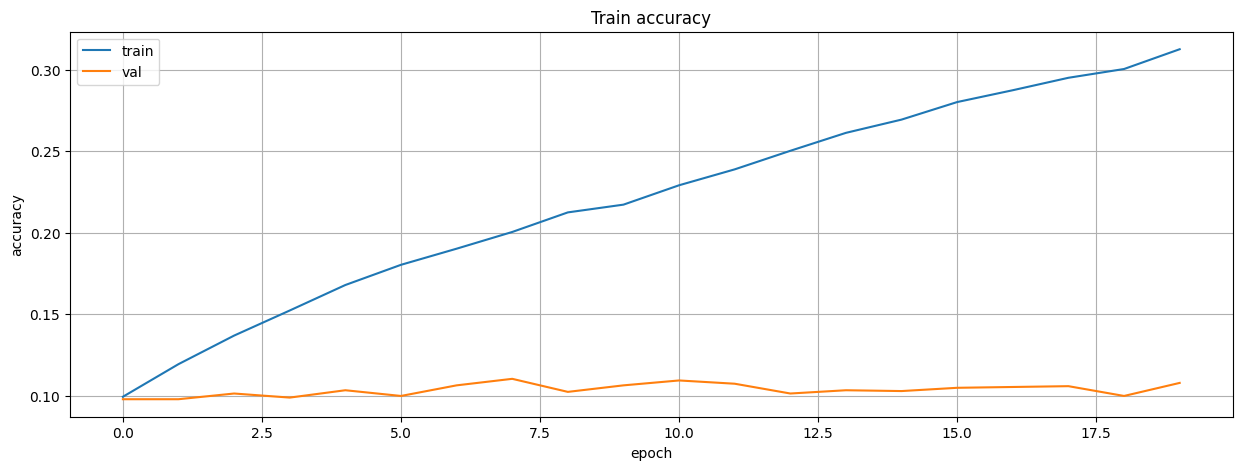

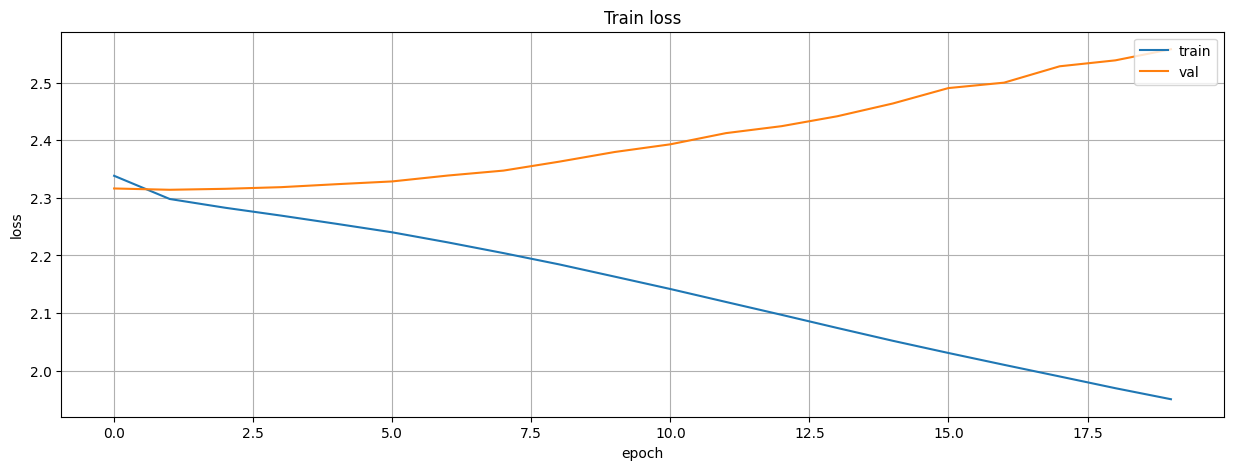

In [15]:
# Summarize history for accuracy
plt.figure(figsize=(15,5))
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('Train accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.grid()
plt.show()

# Summarize history for loss
plt.figure(figsize=(15,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Train loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.grid()
plt.show()

# 6. Evaluate the model on test set

In [16]:
results = model.evaluate(x_test, y_test, batch_size=128, return_dict=True)
print( results )

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.0961 - loss: 2.5695
{'acc': 0.1014999970793724, 'loss': 2.538170337677002}


# 7. Inference

In [17]:
# Test using the model on x_test[i]
i = 0
y_pred = model.predict( x_test[i].reshape(1,-1) )   # Reshape x_test[i] from (n_feature,) to (1, n_feature)

print( f"{'#'*10} Input: x_test[{i}] {'#'*10}" )
print( f"shape={x_test[i].shape}\nvalue={x_test[i]}\n" )

print( f"{'#'*10} Ground truth: y_test[{i}] {'#'*10}" )
print( f"shape={y_test[i].shape}\nvalue={y_test[i]}\n" )

print( f"{'#'*10} Prediction: y_pred {'#'*10}" )
print( f"type={type(y_pred)}\ndtype={y_pred.dtype}\nshape={y_pred.shape}" )
print( f"value={y_pred}" )
print( f"np.argmax(y_pred)={np.argmax(y_pred)}" )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
########## Input: x_test[0] ##########
shape=(100,)
value=[ 5.10549903e-01 -1.83352447e+00 -1.49723217e-01  1.11129284e+00
  1.42249716e-02 -5.62348604e-01  9.51292276e-01 -6.17010534e-01
 -3.60237151e-01 -1.38861024e+00  4.92188305e-01  1.01176178e+00
  1.80850446e+00  5.89353263e-01  1.36130667e+00 -5.62302768e-03
 -7.39900172e-01  2.56012976e-02  2.96016812e-01  1.08451247e+00
 -1.32617605e+00 -2.80883074e-01 -1.16435957e+00 -5.38934112e-01
 -2.56118089e-01 -1.22306556e-01 -3.43174607e-01 -6.91529632e-01
  7.18301907e-02 -1.80278540e+00 -1.04563855e-01  1.32607853e+00
  9.78216887e-01 -1.11498392e+00 -5.67678213e-01 -1.33293435e-01
  1.21934079e-01  4.03834641e-01 -9.09104645e-01 -1.77769288e-01
 -3.14136744e-01 -4.53699589e-01  1.23750997e+00  3.33860934e-01
 -3.71486664e-01  5.12168765e-01 -1.69686899e-01  2.44636559e+00
  1.00375104e+00  1.39884210e+00 -8.26856732e-01  6.08823121e-01
 -1.26637721e+00  1.69943726e+00  1.27452350e+00 -1.6371628